# Plotting with Seaborn
## Milestone 4: Visualization of Pairwise Relationships

### Objective
In this milestone, you will create a grid of plots, one plot for each type of occupation. Each plot will display the distribution of the ‘age’ and ‘hours-per-week’ columns of your dataset. Your plots should differentiate data for two sexes.

### Importance to project
A facetgrid showing multiple plots simultaneously helps in easy identification of variations in data among separate categories.

### 1. Import the required libraries and read the cleaned dataset into a DataFrame

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Dataset
Features in the data:

- **age**: Age in years (Continuous)
- **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked (Categorical)
- **fnlwgt**: Final weight, a weight factor computed by Census Bureau (Continuous)
- **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool (Categorical)
- **education_num**: Number of years of education completed (Continuous)
- **marital_status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse (Categorical)
- **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces (Categorical)
relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried (Categorical)
- **race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black (Categorical)
- **sex**: Female, Male (Categorical)
- **capital_gain**: Income from sources other than salary (Continuous)
- **capital_loss**: Loss of income (Continuous)
- **hours_per_week**: Hours worked per week (Continuous)
- **native_country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holland-Netherlands.
- **workclass_sc**:
- **education_sc**:
- **marital_status_sc**: 
- **occupation_sc**: 

In [2]:
data_loc = "./data/"
img_loc = "./img/"

In [3]:
df = pd.read_csv(data_loc+"cleaned_adult_consensus.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       30162 non-null  int64 
 1   workclass                 30162 non-null  object
 2   education                 30162 non-null  object
 3   education_num             30162 non-null  int64 
 4   marital_status            30162 non-null  object
 5   occupation                30162 non-null  object
 6   sex                       30162 non-null  object
 7   capital_gain              30162 non-null  int64 
 8   capital_loss              30162 non-null  int64 
 9   hours_per_week            30162 non-null  int64 
 10  native_country            30162 non-null  object
 11  discretized_gross_income  30162 non-null  object
 12  workclass_sc              30162 non-null  object
 13  education_sc              30162 non-null  object
 14  marital_status_sc     

In [5]:
df.sample(5)

,age,workclass,education,education_num,marital_status,occupation,sex,capital_gain,capital_loss,hours_per_week,native_country,discretized_gross_income,workclass_sc,education_sc,marital_status_sc,occupation_sc
8168,46,Private,Assoc-acdm,12,Never-married,Adm-clerical,Female,0,0,47,Cuba,<=50K,Private,Assoc-acdm,Never-married,Adm-clerical
24372,42,Private,11th,7,Married-civ-spouse,Machine-op-inspct,Male,0,0,40,United-States,<=50K,Private,School,Married,Service
28570,30,Private,Prof-school,15,Never-married,Prof-specialty,Male,0,1590,80,United-States,<=50K,Private,Prof-school,Never-married,Professional
8572,31,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Female,4386,0,40,United-States,>50K,Private,HS-grad,Married,Service
11868,19,Private,Some-college,10,Never-married,Sales,Female,0,0,15,United-States,<=50K,Private,Some-college,Never-married,Sales


### 2. Visualize occupation-wise distribution of ages.

You may want to plot a histogram of the Age column for each category in the occupation column.
This can be done by adding a histplot to an instance of facetgrid using the map() function.

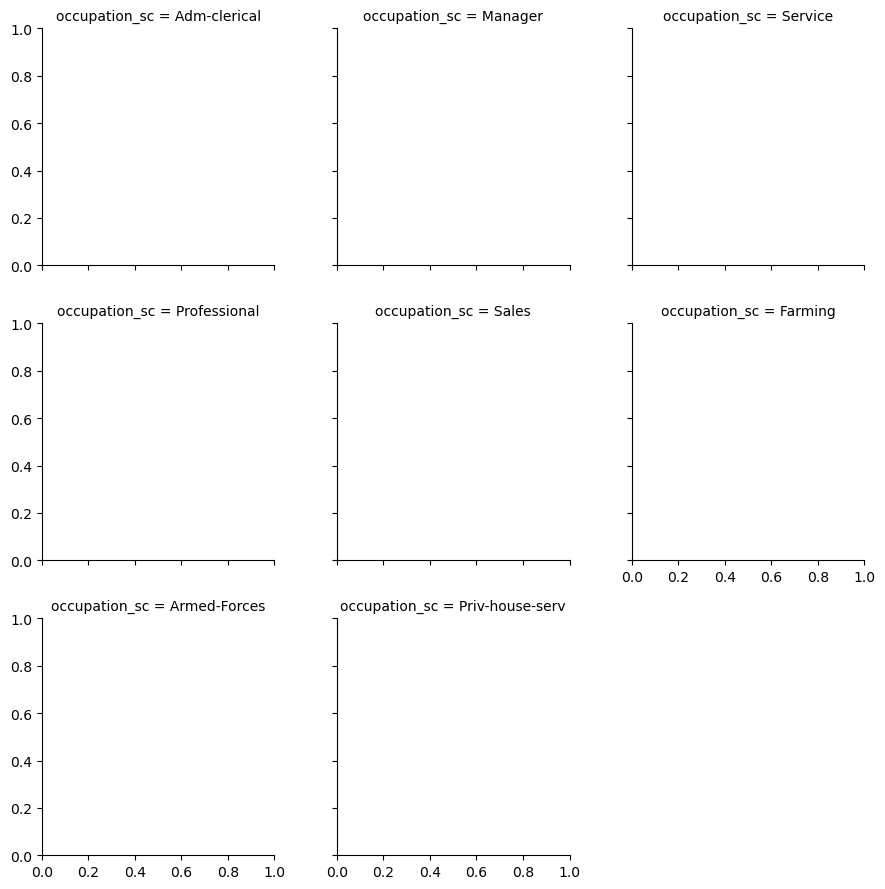

In [6]:
g1 = sns.FacetGrid(df, 
                   col = "occupation_sc" , 
                   col_wrap = 3)
plt.show()

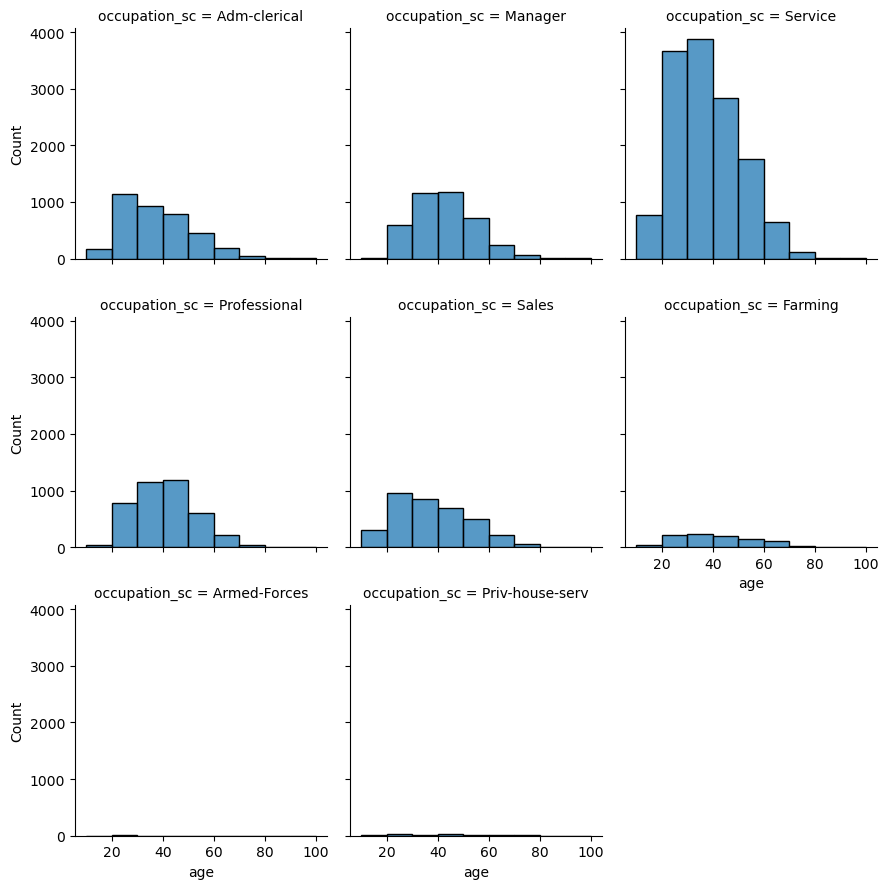

In [7]:
g1 = sns.FacetGrid(df, col = "occupation_sc"
                   , col_wrap = 3)
g1.map(sns.histplot, "age", bins = np.arange(10,110,10))
plt.show()

In [8]:
type(g1)

seaborn.axisgrid.FacetGrid

### 3. Customize your plots.

- Set limits and ticks for the x-axis and y-axis.   
- Set titles for x-axis, y-axis, and plot title.

In [9]:
bins = np.arange(10,110,10)
list(bins)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

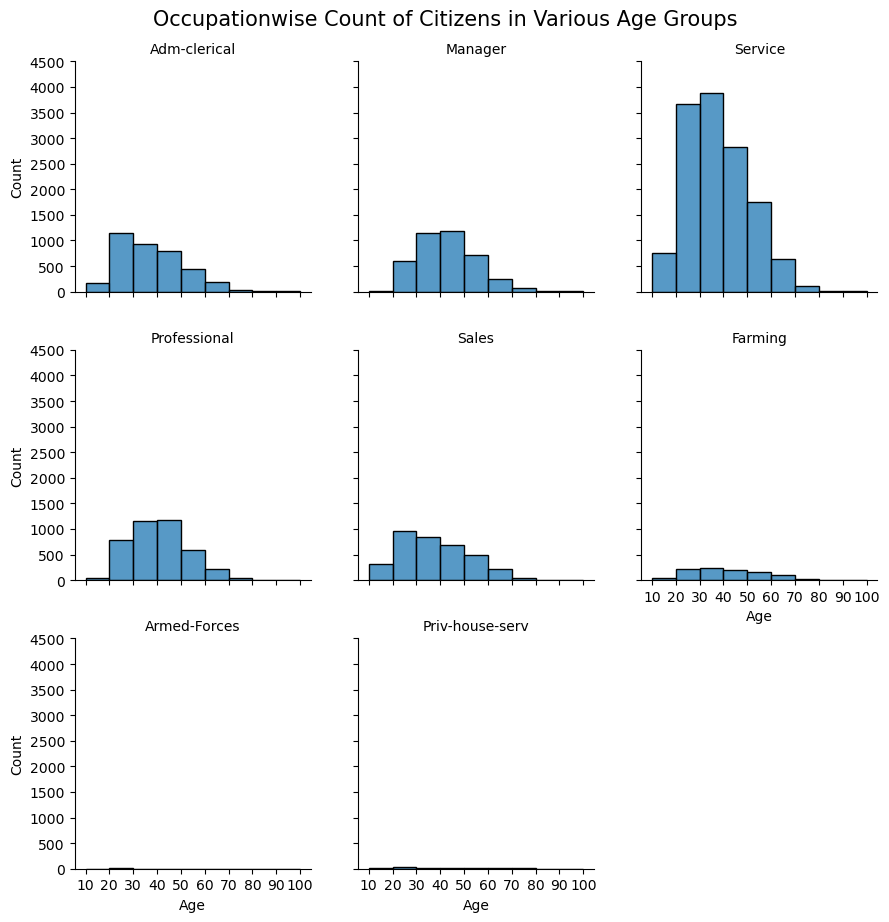

In [10]:
g1 = sns.FacetGrid(df, col = "occupation_sc", col_wrap = 3)
g1.map(sns.histplot, "age", bins = np.arange(10,110,10))

g1.set_axis_labels("Age")

g1.set_titles(col_template="{col_name}")

g1.figure.suptitle("Occupationwise Count of Citizens in Various Age Groups",
                   size = 15, y = 1.02)

g1.set(xticks = np.arange(10,110,10), 
       yticks = np.arange(0,5000,500))

g1.figure.subplots_adjust(wspace = 0.2)
g1.figure.savefig(img_loc+"facetgrid_age_by_occupation.png", dpi=300, bbox_inches="tight")
plt.show()

#### Code Explanation


#### **1. Plot Overview**

* This figure uses **Faceted Histograms**: a histogram of `age` is created separately for each `occupation_sc` category.
* The **x-axis** shows `Age` (10–100 in bins of 10).
* The **y-axis** shows the `Count` of individuals within each age bin.
* Each small subplot corresponds to one occupational group (e.g., *Manager*, *Service*, *Sales*).
* Arranged in a grid with up to 3 plots per row (`col_wrap=3`).

This visualization helps answer:

* *How is the age distribution shaped within each occupation?*
* *Are there differences across occupational categories?*

---

#### **2. Code Breakdown**

```python
g1 = sns.FacetGrid(df, col="occupation_sc", col_wrap=3)
```

* Creates a grid of subplots, one per occupation.
* `col_wrap=3` → places at most 3 plots in a row.

```python
g1.map(sns.histplot, "age", bins=np.arange(10,110,10))
```

* Maps a histogram of `age` into each subplot.
* Uses bins from 10 to 100 in steps of 10.

```python
g1.figure.savefig("facetgrid_age_by_occupation.png", dpi=300, bbox_inches="tight")
```

* Saves the whole grid figure as a PNG file.

```python
plt.show()
```

* Displays the figure.

---

#### **3. Questions for Reflecting on Visual Elements**

* Q1. What do you notice about the overall shape of the histograms across occupations — are they similar or different?
* Q2. How does the y-axis scale compare across occupations? (They all share the same scale, which makes comparisons easier but may exaggerate small categories.)
* Q3. What effect does the grid arrangement have on how easy it is to compare occupations side by side?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* Q1. Which occupations have the largest counts (e.g., *Service* has very high counts, while *Armed-Forces* is almost empty)?
* Q2. What age ranges dominate different occupations? For example, *Adm-clerical* and *Manager* skew towards working-age adults (20–50).
* Q3. Are there occupations with a wider spread of ages (like *Service*) versus those with narrower distributions (like *Professional*)?
* Q4. What does the near-empty *Armed-Forces* subplot suggest about the dataset? (Very few individuals coded to that occupation.)

---

#### **5. Learning Points**

* **FacetGrid** is powerful for comparing distributions across categorical groups.
* Using consistent binning and scales makes patterns directly comparable.
* **Common mistakes:** Forgetting that rare categories (like *Armed-Forces*) may look blank due to low counts.
* **One suggestion for improvement:** Add titles, colors, or annotations (e.g., mean age per occupation) to make differences stand out more clearly.

---

**Key takeaway:**
This FacetGrid shows that most occupations share a concentration of working-age adults (20–50), with *Service* dominating in count. Some occupations (like *Armed-Forces* and *Priv-house-serv*) have very few observations, suggesting either small representation in the dataset or missing data.


<details><summary style="font-size: 1.1em; font-weight: bold;">Click to show answers</summary>

#### Answers

## **3. Questions for Reflecting on Visual Elements**

**Q1. What do you notice about the overall shape of the histograms across occupations — are they similar or different?**

* Most occupations show a bell-like distribution centered on working ages (20–50). The shapes are broadly similar, but the height of the bars differs depending on how many people are in each occupation.

**Q2. How does the y-axis scale compare across occupations?**

* All subplots share the same y-axis scale (up to \~4500). This makes comparisons consistent, but it also means smaller occupations (like *Armed-Forces* or *Priv-house-serv*) look nearly empty compared to *Service*.

**Q3. What effect does the grid arrangement have on how easy it is to compare occupations side by side?**

* The grid layout allows you to quickly compare patterns across categories, but with many subplots it can feel crowded. Still, it makes similarities (like concentration in working ages) easy to spot.

---

## **4. Data Interpretation: Explore these questions to deepen your understanding**

**Q1. Which occupations have the largest counts?**

* *Service* has by far the highest counts, followed by *Adm-clerical*, *Professional*, and *Sales*. *Armed-Forces* has almost no entries.

**Q2. What age ranges dominate different occupations?**

* In nearly all occupations, the dominant age range is 20–50 years old. Very few individuals are younger than 20 or older than 60.

**Q3. Are there occupations with a wider spread of ages?**

* *Service* shows the broadest spread, extending into older age ranges, while others like *Professional* and *Manager* are more tightly concentrated.

**Q4. What does the near-empty Armed-Forces subplot suggest?**

* That there are very few individuals with this occupation in the dataset. It highlights the importance of recognizing data imbalance across categories.

---

**Summary:**
The FacetGrid shows that age distributions across occupations are quite similar — concentrated in working ages — but the number of individuals in each occupation varies dramatically, with *Service* dominating and categories like *Armed-Forces* nearly absent.
    
</summary>

In [11]:
df[["occupation_sc","age"]].groupby("occupation_sc").count().sort_values(by="age")

,age
occupation_sc,
Armed-Forces,9
Priv-house-serv,143
Farming,989
Sales,3584
Adm-clerical,3721
Manager,3992
Professional,4038
Service,13686


### 4. Save your plot with the desired resolution.

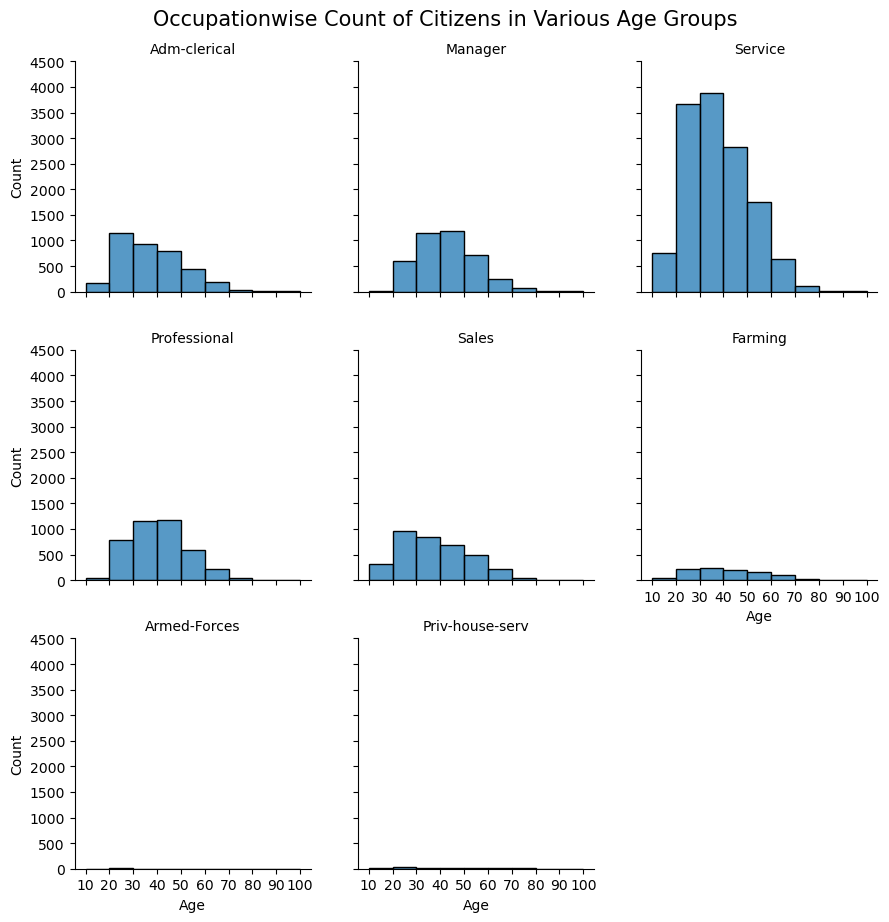

In [12]:
g1 = sns.FacetGrid(df, col = "occupation_sc", col_wrap = 3)
g1.map(sns.histplot, "age", bins = np.arange(10,110,10))

g1.set_axis_labels("Age")

g1.set_titles(col_template="{col_name}")

g1.figure.suptitle("Occupationwise Count of Citizens in Various Age Groups", 
                   size = 15, y = 1.02)

g1.set(xticks = np.arange(10,110,10), 
       yticks = np.arange(0,5000,500))

g1.figure.subplots_adjust(wspace = 0.2)

plt.show()

In [13]:
g1.savefig(img_loc+"Occupation_histograms.png", dpi = 400)

### 5. Visualize occupation-wise values of ages and hours worked per week.

- Create an instance of facetgrid that displays a subplot for each occupation category along columns.   
- Add a scatterplot to each facet of the facetgrid created above with Age on the x-axis and ‘hours-per-week’ on the y-axis.   
- Add a reference line indicating median value of hours per week to each subplot.   

In [14]:
df.occupation_sc.unique()

array(['Adm-clerical', 'Manager', 'Service', 'Professional', 'Sales',
       'Farming', 'Armed-Forces', 'Priv-house-serv'], dtype=object)

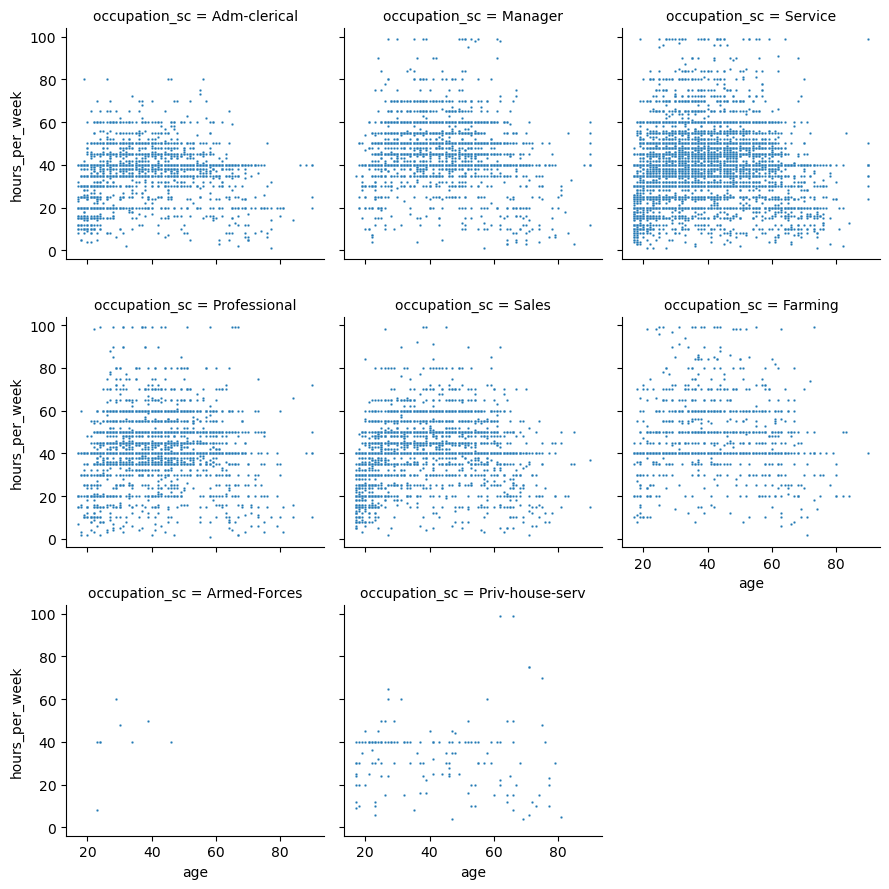

In [15]:
g2 = sns.FacetGrid(df, col = "occupation_sc", col_wrap = 3)
g2.map(sns.scatterplot, "age", "hours_per_week", s = 3)
plt.show()

#### Add Reference Line

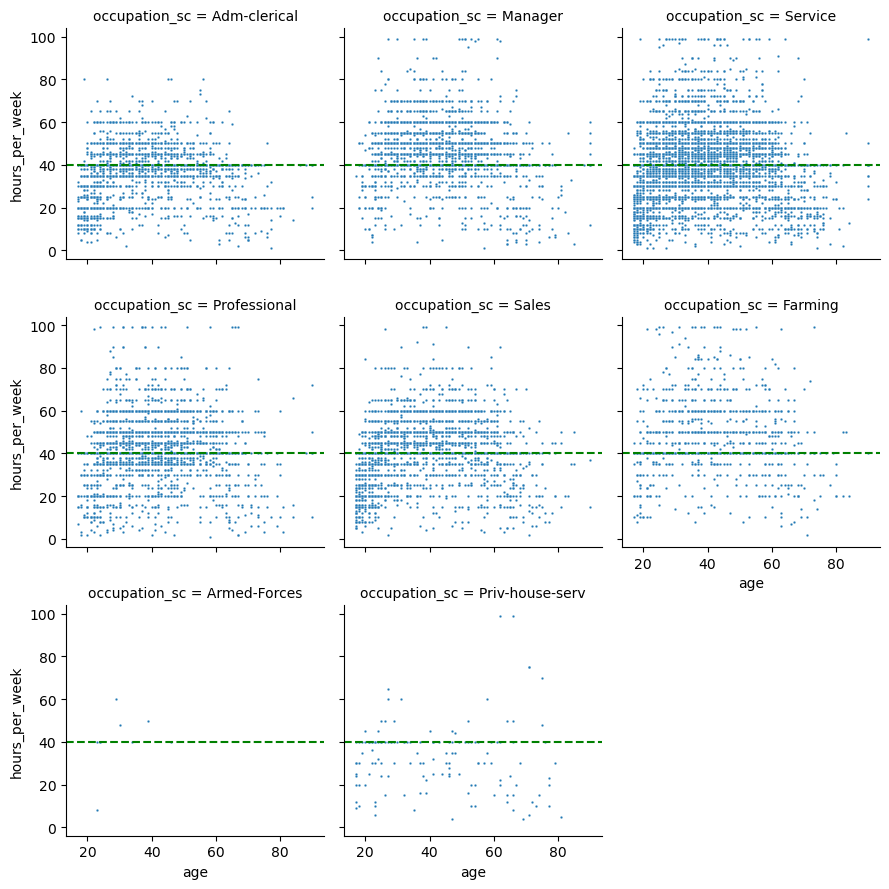

In [16]:
g2 = sns.FacetGrid(df, col = "occupation_sc", 
                   col_wrap = 3)
g2.map(sns.scatterplot, "age", "hours_per_week",
                   s = 3)

g2.refline(y = df.hours_per_week.median(), 
           color = "green")

plt.show()

### 6. Conditionally change the color of a facet.

- For the facet that shows data of occupation Professional, set the face color to 'red’.  
- For all other occupations, set the face color to 'palegreen’.

In [17]:
sns.color_palette("Accent")

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314),
 (1.0, 1.0, 0.6),
 (0.2196078431372549, 0.4235294117647059, 0.6901960784313725),
 (0.9411764705882353, 0.00784313725490196, 0.4980392156862745),
 (0.7490196078431373, 0.3568627450980392, 0.09019607843137253),
 (0.4, 0.4, 0.4)]

In [18]:
print(sns.color_palette("Accent").as_hex())

['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#f0027f', '#bf5b17', '#666666']


In [19]:
sns.color_palette("gnuplot2")

[(0.0, 0.0, 0.5647058823529412),
 (0.11335784313725483, 0.0, 1.0),
 (0.5545343137254901, 0.014901960784313717, 0.9850980392156864),
 (1.0, 0.30509803921568623, 0.6949019607843139),
 (1.0, 0.5874509803921569, 0.4125490196078432),
 (1.0, 0.8776470588235293, 0.12235294117647078)]

In [20]:
print(sns.color_palette("gnuplot2").as_hex())

['#000090', '#1d00ff', '#8d04fb', '#ff4eb1', '#ff9669', '#ffe01f']


In [21]:
sns.color_palette("Greys")

[(0.9295040369088812, 0.9295040369088812, 0.9295040369088812),
 (0.819115724721261, 0.819115724721261, 0.819115724721261),
 (0.6770011534025375, 0.6770011534025375, 0.6770011534025375),
 (0.5085736255286428, 0.5085736255286428, 0.5085736255286428),
 (0.35912341407151094, 0.35912341407151094, 0.35912341407151094),
 (0.1679354094579008, 0.1679354094579008, 0.1679354094579008)]

In [22]:
print(sns.color_palette("Greys").as_hex())

['#ededed', '#d1d1d1', '#adadad', '#828282', '#5c5c5c', '#2b2b2b']


In [23]:
g2.axes_dict

{'Adm-clerical': <Axes: title={'center': 'occupation_sc = Adm-clerical'}, ylabel='hours_per_week'>,
 'Manager': <Axes: title={'center': 'occupation_sc = Manager'}>,
 'Service': <Axes: title={'center': 'occupation_sc = Service'}>,
 'Professional': <Axes: title={'center': 'occupation_sc = Professional'}, ylabel='hours_per_week'>,
 'Sales': <Axes: title={'center': 'occupation_sc = Sales'}>,
 'Farming': <Axes: title={'center': 'occupation_sc = Farming'}, xlabel='age'>,
 'Armed-Forces': <Axes: title={'center': 'occupation_sc = Armed-Forces'}, xlabel='age', ylabel='hours_per_week'>,
 'Priv-house-serv': <Axes: title={'center': 'occupation_sc = Priv-house-serv'}, xlabel='age'>}

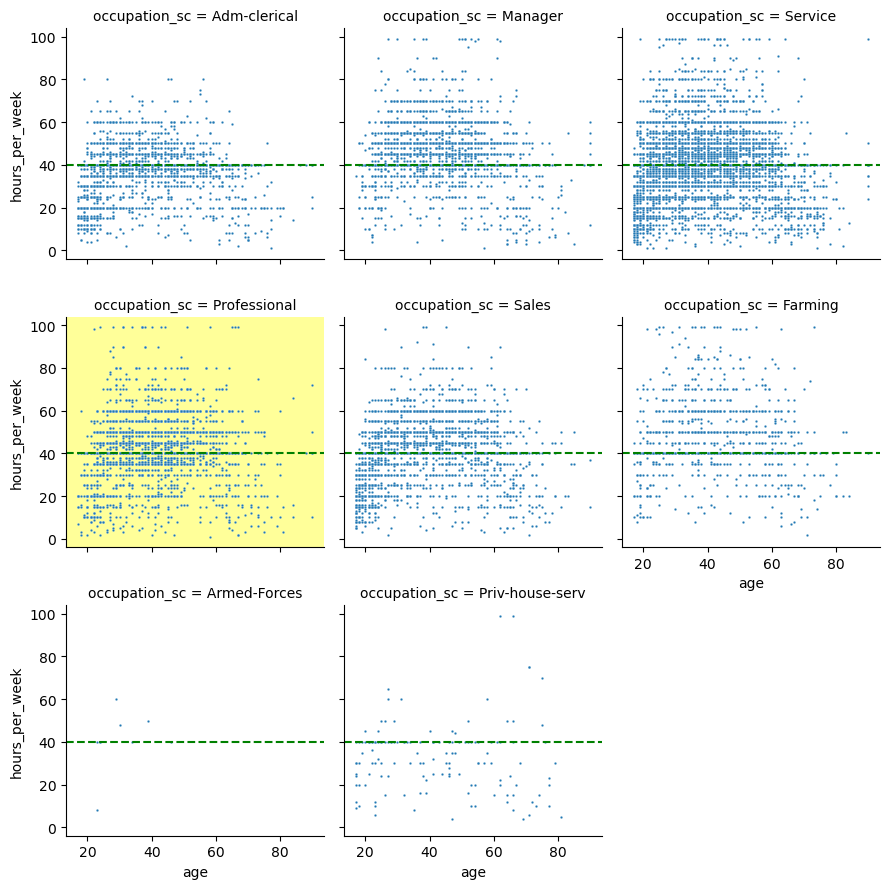

In [24]:
g2 = sns.FacetGrid(df, col = "occupation_sc", 
                   col_wrap = 3)
g2.map(sns.scatterplot, "age", "hours_per_week",
                   s = 3)
g2.refline(y = df.hours_per_week.median(), 
           color = "green")

prof_ax = g2.axes_dict["Professional"]
prof_ax.set_facecolor('#ffff99')

plt.show()

#### Add Titles and Labels

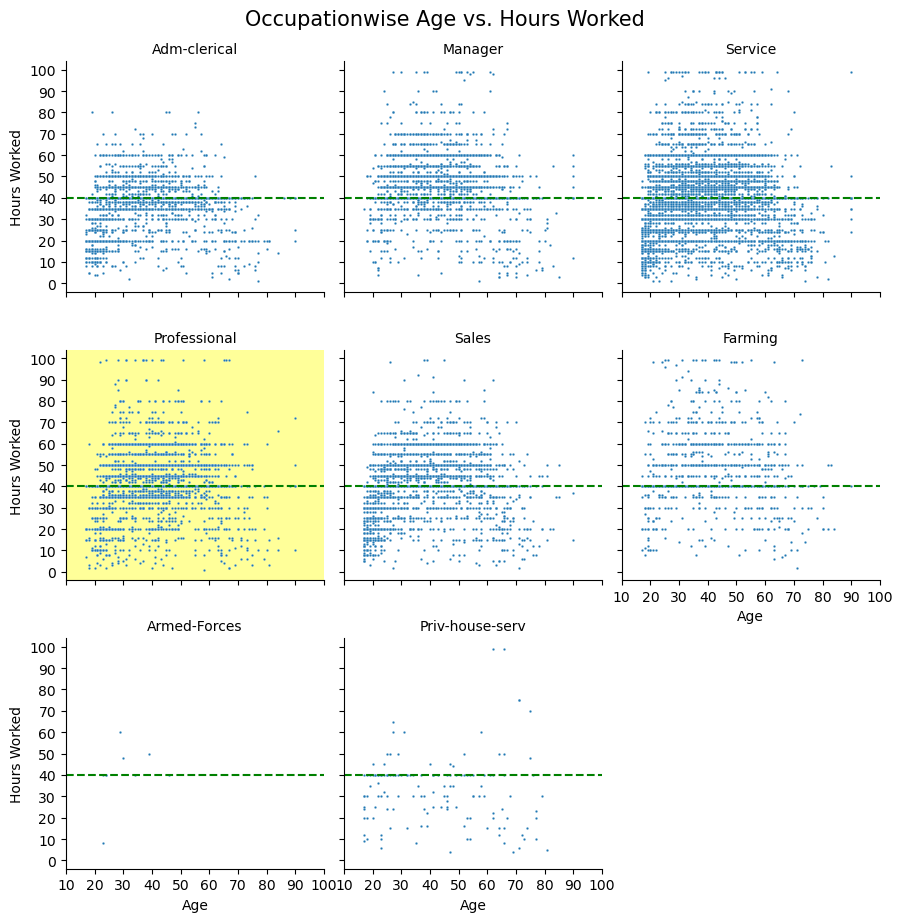

In [25]:
g2 = sns.FacetGrid(df, col = "occupation_sc", col_wrap = 3)
g2.map(sns.scatterplot, "age", "hours_per_week", s = 3)
g2.refline(y = df.hours_per_week.median(), color = "green")

prof_ax = g2.axes_dict["Professional"]
prof_ax.set_facecolor('#ffff99')

g2.set_axis_labels("Age","Hours Worked")

g2.set_titles(col_template="{col_name}")

g2.figure.suptitle("Occupationwise Age vs. Hours Worked", 
                   size = 15, y = 1.02)

g2.set(xticks = np.arange(10,110,10), 
       yticks = np.arange(0,110,10))

g2.savefig(img_loc+"Occupation_scatterplots.png" , dpi = 400)
plt.show()